In [1]:

%pip install geopandas matplotlib


In [2]:

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


%matplotlib inline


In [3]:

congress_path = "california-congressional-districts.geojson"
leg_path = "CA_Legislative_Districts.csv"

gdf_congress = gpd.read_file(congress_path)


leg = pd.read_csv(leg_path)

print("Congressional districts columns:", gdf_congress.columns)
print("Legislative districts columns:", leg.columns)

Congressional districts columns: Index(['Name', 'description', 'descriptio', 'geometry'], dtype='object')
Legislative districts columns: Index(['OBJECTID', 'ID', 'AREA', 'DISTRICT', 'MEMBERS', 'NAME', 'POPULATION',
       'CVAP_19', 'HSP_CVAP_1', 'DOJ_NH_BLK', 'DOJ_NH_ASN', 'NH_WHT_CVA',
       'IDEAL_VALU', 'DEVIATION', 'F_DEVIATIO', 'MULTIPLE_F', 'F_CVAP_19',
       'F_HSP_CVAP', 'F_DOJ_NH_B', 'F_DOJ_NH_A', 'F_NH_WHT_C', 'DISTRICT_L',
       'DISTRICT_N', 'SHAPE_Length', 'SHAPE_Area'],
      dtype='object')


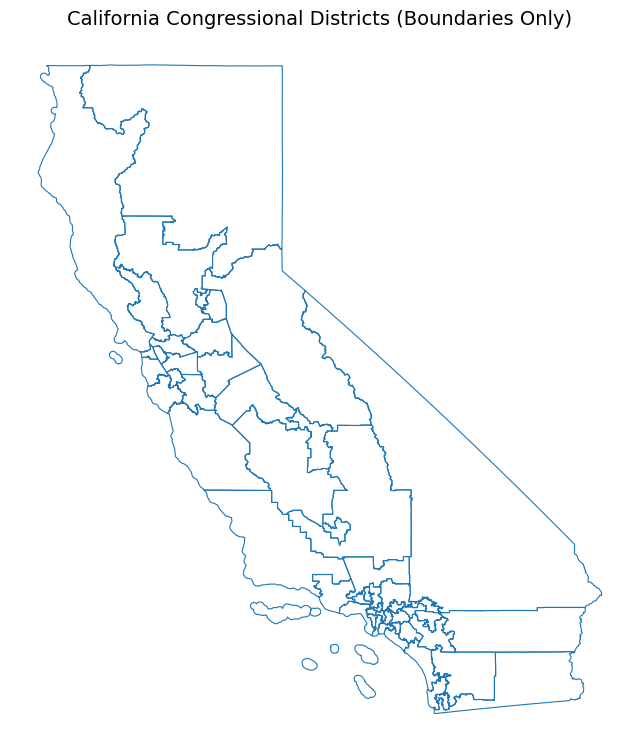

In [4]:
fig, ax = plt.subplots(figsize=(8, 10))

gdf_congress.boundary.plot(ax=ax, linewidth=0.8)

ax.set_title("California Congressional Districts (Boundaries Only)", fontsize=14)
ax.axis("off")
plt.show()

In [5]:
gdf_congress["DISTRICT"] = gdf_congress["Name"].astype(int)


leg_pop = leg[["DISTRICT", "POPULATION"]].copy()

display(leg_pop.head())

,DISTRICT,POPULATION
0,1,760066
1,10,760066
2,11,760067
3,12,760065
4,13,760065


In [6]:
gdf_merged = gdf_congress.merge(leg_pop, on="DISTRICT", how="left")

display(gdf_merged[["Name", "DISTRICT", "POPULATION"]].head())

,Name,DISTRICT,POPULATION
0,01,1,760066.0
1,02,2,760067.0
2,03,3,760065.0
3,04,4,760065.0
4,05,5,760065.0


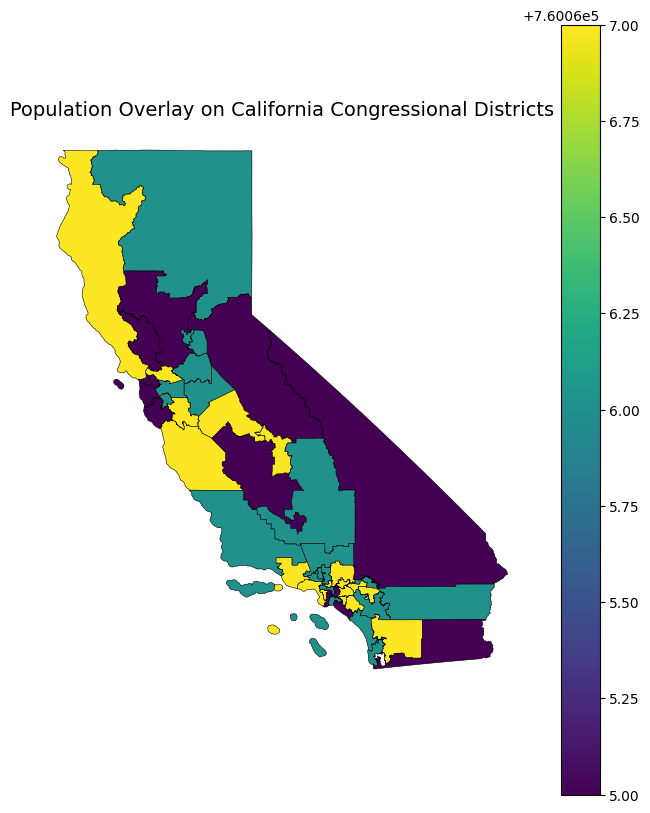

In [7]:
fig, ax = plt.subplots(figsize=(8, 10))


gdf_merged.plot(
    column="POPULATION",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.4
)

ax.set_title("Population Overlay on California Congressional Districts", fontsize=14)
ax.axis("off")
plt.show()

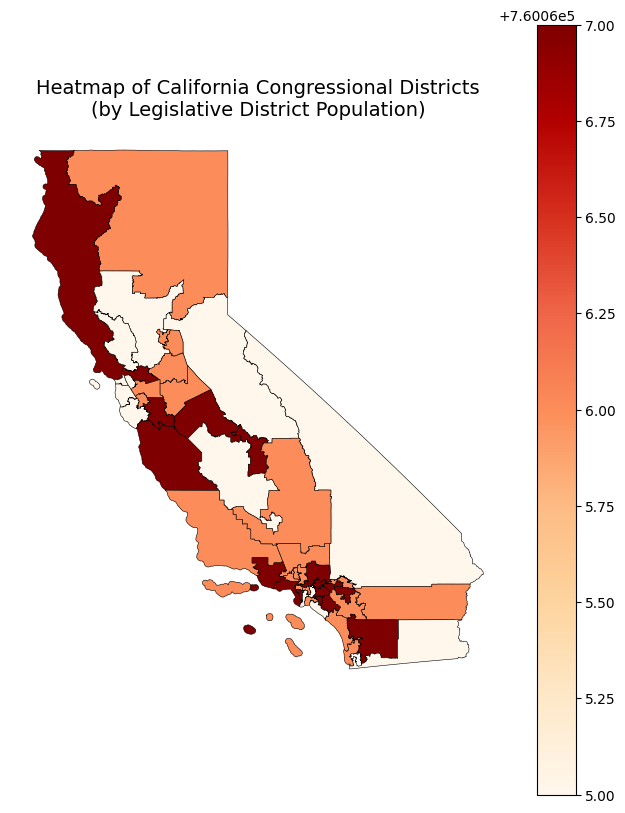

In [8]:
fig, ax = plt.subplots(figsize=(8, 10))


gdf_merged.plot(
    column="POPULATION",
    ax=ax,
    legend=True,
    cmap="OrRd",
    edgecolor="black",
    linewidth=0.4
)

ax.set_title("Heatmap of California Congressional Districts\n(by Legislative District Population)", fontsize=14)
ax.axis("off")
plt.show()